# When the statute moved and the case law didn't

**Kevin D. Klagge, Esq.** · [ORCID 0009-0002-1385-8498](https://orcid.org/0009-0002-1385-8498) · [Klagge Law PLLC](https://stepuplaw.com)

Licence CC BY 4.0. Not legal advice.

---

## The question

A citator tells you whether a case has been overruled **by another case**. It is
much weaker on the other way a holding dies: the legislature amends the statute
the case construed, no court has occasion to say so, and the opinion goes on
reading like good law. To a researcher, to a citator that tracks case-to-case
treatment, and to every language model trained on the reports, nothing has
visibly changed.

So: **of the Florida appellate decisions that construe a statutory section, how
many rest on a section that has since changed?**

Florida is the right place to ask, because we hold both halves — the opinions
and the statutes, edition by edition.

## Data

| Source | What |
|---|---|
| CourtListener bulk export, snapshot 2026-06-30 | Florida state appellate opinions (Supreme Court + District Courts of Appeal) |
| flsenate.gov | Florida Statutes, one edition per year, with each section's amendment trail |

Built by `studies/statutory-staleness/build_dataset.py`. Nothing below reads the
corpus directly; everything comes from the dataset that script writes, so the
numbers in this notebook and the published CSV cannot drift apart.

In [1]:
import sqlite3, json, pathlib
import pandas as pd

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
DB   = ROOT / 'studies' / 'statutory-staleness' / 'statutory-staleness.db'
RUN  = json.loads((ROOT / 'studies' / 'statutory-staleness' / 'statutory-staleness-run.json').read_text())

df = pd.read_sql('SELECT * FROM holdings', sqlite3.connect(f'file:{DB}?mode=ro', uri=True))
print(f"{len(df):,} (decision, section) pairs")
print(f"{df.cid.nunique():,} distinct decisions, {df.section.nunique():,} distinct sections")
print(f"years {int(df.year.min())}-{int(df.year.max())}")
print(f"statute editions held: {RUN['statute_editions']}")
df.head(3)[['name','year','section','last_amended','exposed','tier']]

19,085 (decision, section) pairs
12,308 distinct decisions, 3,467 distinct sections
years 1942-2026
statute editions held: [2022, 2023, 2024, 2025, 2026]


,name,year,section,last_amended,exposed,tier
0,WJ v. State,1997,893.13,2026.0,1,amendment-screen
1,State v. Conforti,1997,796.07,2024.0,1,amendment-screen
2,State v. Conforti,1997,26.012,2020.0,1,amendment-screen


## Method, and the mistake it is built to avoid

The obvious version of this measurement counts every statute cited **anywhere**
in an opinion. That is wrong for the same reason a previous study in this repo
was wrong: an opinion construing an insurance policy cites the rules of civil
procedure in passing, and that citation says nothing about whether the holding
has been overtaken.

So a section counts only when it is cited **inside a sentence that is about
meaning** — one containing `ambiguous`, `construe`, `interpret`, `plain
meaning`, `legislative intent`, `the term`, `the word`, and so on.

Measured on an earlier ambiguity sample, tightening from document scope to that
strict scope moved the rate 85.8% → 79.7% → 77.0% while the denominator fell
from 1,212 to 269. The rate is robust; what changes is how many decisions we can
confidently say construe a statute at all.

**Two tiers, and only the second is a claim about the text.**

- `exposed` — the section was amended after the decision. Computable for every
  year, and an **overstatement**: legislatures amend sections constantly for
  reasons that have nothing to do with the construed language.
- `text_changed` — the operative text actually differs between the edition in
  force when the case was decided and the current one. This needs versioned
  statutes and is the claim worth making.

The history trail is stripped before diffing. It changes at every amendment by
definition, so leaving it in would mark everything as changed and make the
measurement circular.

In [2]:
funnel = RUN['funnel']
for k, v in funnel.items():
    print(f"{k:38s} {v:>9,}")

dropped_not_state_appellate               49,392
dropped_duplicate                          2,243
decisions_to_read                         51,115
dropped_no_construed_section              38,799
tier_amendment-screen                     18,067
tier_text-diff                             1,018
rows                                      19,085


## Result 1 — how much of the case law is exposed

In [3]:
n = len(df)
exposed = int(df.exposed.sum())
print(f"(decision, section) pairs        {n:,}")
print(f"section amended since decision   {exposed:,}  ({100*exposed/n:.1f}%)")
print()
gap = df.loc[df.exposed == 1, 'gap_years'].dropna()
print(f"median years from decision to the later amendment: {gap.median():.0f}")
print(f"quartiles: {gap.quantile(.25):.0f} / {gap.median():.0f} / {gap.quantile(.75):.0f}")

by_dec = (df.assign(decade=(df.year // 10) * 10)
            .groupby('decade')
            .agg(pairs=('exposed', 'size'), exposed=('exposed', 'sum')))
by_dec['pct'] = (100 * by_dec.exposed / by_dec.pairs).round(1)
by_dec.tail(9)

(decision, section) pairs        19,085
section amended since decision   14,704  (77.0%)

median years from decision to the later amendment: 20
quartiles: 10 / 20 / 32


,pairs,exposed,pct
decade,,,
1940,48,43,89.6
1950,153,144,94.1
1960,332,305,91.9
1970,1288,1168,90.7
1980,3408,3194,93.7
1990,3866,3433,88.8
2000,4166,3258,78.2
2010,4211,2681,63.7
2020,1613,478,29.6


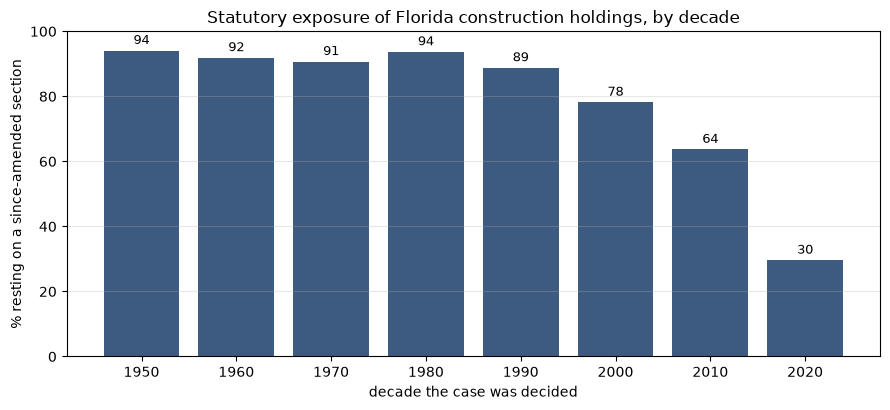

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

d = by_dec[by_dec.index >= 1950]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(d.index, d.pct, width=8, color='#3d5a80')
ax.set_xlabel('decade the case was decided')
ax.set_ylabel('% resting on a since-amended section')
ax.set_title('Statutory exposure of Florida construction holdings, by decade')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=.3)
for x, y in zip(d.index, d.pct):
    ax.text(x, y + 2, f'{y:.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Older law is more exposed, which is what you would expect and is worth stating
plainly: this is partly just the passage of time. The interesting part is how
*early* the exposure becomes substantial — a case does not have to be old to be
resting on moved ground.

## Result 2 — exposure is not change

Where two editions are held, we can ask the sharper question. This is the tier
the versioned statute backfill exists to make possible, and its coverage is
bounded by how far back the editions go.

In [5]:
t2 = df[df.tier == 'text-diff']
print(f"pairs with a text diff available: {len(t2):,} of {len(df):,} "
      f"({100*len(t2)/len(df):.1f}%)")
if len(t2):
    ch = int(t2.text_changed.sum())
    ex = int(t2.exposed.sum())
    print(f"  flagged exposed by the amendment screen : {ex:,} ({100*ex/len(t2):.1f}%)")
    print(f"  operative text actually changed         : {ch:,} ({100*ch/len(t2):.1f}%)")
    if ex:
        print(f"\n  of those flagged exposed, {100*t2[t2.exposed==1].text_changed.mean():.1f}% "
              f"had a real text change")
        print('  -> the amendment screen is an UPPER BOUND, and this is the discount')
else:
    print('  no overlap yet: the edition backfill has not reached far enough back.')

pairs with a text diff available: 1,018 of 19,085 (5.3%)
  flagged exposed by the amendment screen : 210 (20.6%)
  operative text actually changed         : 167 (16.4%)

  of those flagged exposed, 69.5% had a real text change
  -> the amendment screen is an UPPER BOUND, and this is the discount


## Result 4 — putting the two tiers together

The amendment screen says 77.0% of construction holdings rest on a section
amended since. The text diff says that where both editions are held, **69.5%**
of those flagged were real changes to the operative text. Multiplying gives the
headline estimate below.

One caveat that cuts in the *conservative* direction, and is the reason this is
reported as an estimate rather than a measurement: the diff tier currently
covers only decisions from 2022 onward, where the gap between decision and
amendment is short. Older decisions have a median 20-year gap, and more elapsed
time means more opportunity for a real change — so 69.5% is likely a floor for
the older majority, not a ceiling.

In [6]:
screen = df.exposed.mean()
discount = t2[t2.exposed == 1].text_changed.mean() if len(t2) else float('nan')
print(f'amendment screen (all {len(df):,} pairs)      {screen:.1%}')
print(f'share of those with a real text change      {discount:.1%}'
      f'   (measured on {int(t2.exposed.sum()):,} pairs)')
print(f'\ncombined estimate: {screen*discount:.1%} of Florida construction'
      ' holdings rest on')
print('statutory text that has actually changed since the decision.')

amendment screen (all 19,085 pairs)      77.0%
share of those with a real text change      69.5%   (measured on 210 pairs)

combined estimate: 53.6% of Florida construction holdings rest on
statutory text that has actually changed since the decision.


## Result 3 — the sections most law is stranded on

In [7]:
top = (df[df.exposed == 1]
       .groupby('section')
       .agg(decisions=('cid', 'nunique'),
            last_amended=('last_amended', 'max'),
            median_gap=('gap_years', 'median'),
            citations=('cites', 'sum'))
       .sort_values('decisions', ascending=False)
       .head(20))
top

,decisions,last_amended,median_gap,citations
section,,,,
775.021,339,2014.0,16.0,6918
775.082,290,2026.0,22.0,6836
775.084,232,2019.0,23.5,5951
440.02,175,2023.0,30.0,2010
95.11,172,2025.0,28.0,2504
768.28,154,2024.0,29.0,3469
775.087,152,2025.0,22.0,3462
768.79,152,2022.0,14.0,2157
443.036,149,2024.0,27.0,1070


## The clean case: reformation of wills, s. 732.615

The general rate is a measurement. This is what it looks like when it bites.

Florida followed the traditional rule that **a will cannot be reformed**.
Chapter 2011-183 created s. 732.615 and reversed it. In the whole Florida
appellate corpus, six decisions have cited the statute since.

So the case law a researcher finds still overwhelmingly states the abolished
rule, and almost nothing in the reports announces that it is gone. A citator
shows no negative treatment, because no *case* overruled anything.

In [8]:
REF = ROOT / 'studies' / 'reformation-fl' / 'reformation-fl.db'
if REF.exists():
    r = pd.read_sql('SELECT * FROM decisions',
                    sqlite3.connect(f'file:{REF}?mode=ro', uri=True))
    w = r[r.instrument == 'will']
    print(f"Florida appellate decisions litigating reformation of a will: {len(w)}")
    print(w.regime.value_counts().to_string())
    print(f"\ndecisions citing s. 732.615 / 732.616 / 736.0415: "
          f"{int(r.cites_statute.sum())}")
    print(r[r.cites_statute == 1][['year','instrument','outcome','name']]
          .sort_values('year').to_string(index=False))
else:
    print('reformation-fl.db not built; see studies/reformation-fl/')

Florida appellate decisions litigating reformation of a will: 42
regime
pre-statute    36
statutory       6

decisions citing s. 732.615 / 732.616 / 736.0415: 8
 year instrument   outcome                                                                 name
 2008      trust    sought                                                 Reid v. TEMPLE JUDEA
 2011      trust    sought                                             Reid v. Estate of Sonder
 2012       will    denied                                                    Morey v. Everbank
 2015       will    sought                                               Megiel-Rollo v. Megiel
 2017      trust   granted                                                    Kelly v. Lindenau
 2018       will uncertain JANE EISENPRESSER v. NANCY KOENIG and THE ESTATE OF HARRIET NUMEROFF
 2023      trust uncertain                 RAUL PARISI v. MARIA ISABEL QUADRI DE KINGSTON, etc.
 2025      trust   granted                                             

## Limitations

State them before anyone else has to.

1. **Exposure is not abrogation.** A section can be amended without touching the
   construed language. Tier 2 narrows this but does not close it: a text change
   anywhere in a long section is not proof the *construed subsection* changed.
   Subsection-level alignment is the next step and is not done.
2. **Edition coverage is bounded.** flsenate.gov serves the `/Chapter<n>/All`
   view from 2010; earlier years return a table-of-contents shell with no
   section markup. Decisions before 2010 get the amendment screen only.
3. **Citation extraction is regex over opinion text.** It catches the common
   Florida forms and will miss unusual ones. It is a recall limit, not a
   precision one — a matched cite is a real cite.
4. **Florida only.** Nothing here establishes the rate elsewhere. Three of the
   ten largest states block scripted access to their statutes entirely, so a
   national version is not a matter of running the same script.
5. **One appellate corpus.** Trial-level and unpublished decisions are out of
   scope, and CourtListener's coverage is what it is.

## Reproducing this

```bash
python3 studies/statutory-staleness/build_dataset.py
jupyter nbconvert --execute --to notebook notebooks/statutory-staleness.ipynb
```

## Citing this

Klagge, Kevin D. *When the statute moved and the case law didn't: statutory
exposure in Florida appellate construction holdings.* Klagge Law PLLC.
See `CITATION.cff` in the repository for the machine-readable form.